## Deep Learning for 4-Class Motor Imagery Decoding 

## 1. Objective
The goal of this module is to build a robust neural decoder capable of classifying four distinct motor imagery tasks (**Left Hand, Right Hand, Feet, and Tongue**) using EEG signals from the BCI Competition IV 2a dataset. 

While 2-class decoding is common, 4-class classification significantly increases the complexity due to the spatial overlap of neural signatures, particularly between the Right Hand and Feet imagery.


## 2. Advanced pipeline features
To achieve high performance and stability, this notebook implements several industry-standard deep learning techniques:

* **Subject pooling:** instead of training on a single subject, we aggregate data from 9 different subjects (~2,600 trials) to build a **Subject-Independent** model.
* **EEGNet architecture:** a compact Convolutional Neural Network specifically designed for EEG, utilizing depthwise and separable convolutions to capture temporal and spatial features.
* **Z-Score normalization:** per-trial standardization to ensure stable gradient descent.
* **Gaussian data augmentation:** injection of controlled white noise to the training manifold to reduce overfitting and improve generalization.
* **Cost-sensitive learning:** implementation of **Class Weights** to mitigate prediction bias across the 4 motor classes.
* **Systematic grid search:** automated hyperparameter optimization (Learning Rate, Dropout, Batch Size) to identify the most stable configuration.


## 3. Signal processing specs
* **Bandwidth:** 1.0 - 40.0 Hz (wide-band strategy to capture Delta through Gamma oscillations).
* **Epoch Window:** 3.0 seconds (from 0.5s to 3.5s post-cue).
* **Sampling Rate:** 250 Hz.
* **Input Shape:** (22 Channels × 751 Samples × 1 Kernel).

## Multiclass data preparation

In [1]:
import mne
import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import itertools
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, AveragePooling2D
from tensorflow.keras.layers import SeparableConv2D, DepthwiseConv2D, BatchNormalization, Flatten, Input
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.optimizers import Adam


# Global parameters for data extraction and processing
CLEAN_DATA_DIR = os.path.join('.', 'cleaned_data_1_40')
EVENT_ID = {'left': 1, 'right': 2, 'foot': 3, 'tongue': 4}
T_MIN, T_MAX = 0.5, 3.5

## Standardized data loading function

In [2]:
def load_multiclass_subject_pro(subject_id):
    """
    Loads EEG data, selects specific channels, and applies Z-score normalization.
    Uses modern MNE picking methods and per-trial standardization.
    """
    file_path = os.path.join(CLEAN_DATA_DIR, f'{subject_id}_clean-raw_1_40.fif')
    raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)
    
    # Pick only the 22 EEG channels
    raw.pick(['eeg']) 
    
    events, _ = mne.events_from_annotations(raw, verbose=False)
    epochs = mne.Epochs(raw, events, event_id=EVENT_ID, tmin=T_MIN, tmax=T_MAX, 
                        baseline=None, preload=True, verbose=False)
    
    X = epochs.get_data(copy=True)
    y = epochs.events[:, -1] - 1
    
    # Z-SCORE NORMALIZATION: Standardizing each trial to mean 0 and std 1
    X = (X - np.mean(X, axis=-1, keepdims=True)) / np.std(X, axis=-1, keepdims=True)
    X = np.expand_dims(X, axis=-1)
    
    return X, y

## Subject pooling

In [3]:
# Create a robust dataset by pooling trials from all 9 subjects
all_subjects = [f'A{i:02d}T' for i in range(1, 10)]
X_list, y_list = [], []

print("Pooling data from all subjects...")
for sub in all_subjects:
    try:
        X_sub, y_sub = load_multiclass_subject_pro(sub)
        X_list.append(X_sub)
        y_list.append(y_sub)
        print(f"Successfully loaded subject: {sub}")
    except Exception as e:
        print(f"Could not load subject {sub}: {e}")

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
print(f"Total dataset shape: {X_all.shape}")

Pooling data from all subjects...


C:\Users\ACER\AppData\Local\Temp\ipykernel_19964\1211596147.py:7: RuntimeWarning: This filename (.\cleaned_data_1_40\A01T_clean-raw_1_40.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)


Successfully loaded subject: A01T


C:\Users\ACER\AppData\Local\Temp\ipykernel_19964\1211596147.py:7: RuntimeWarning: This filename (.\cleaned_data_1_40\A02T_clean-raw_1_40.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)


Successfully loaded subject: A02T


...

Successfully loaded subject: A07T


C:\Users\ACER\AppData\Local\Temp\ipykernel_19964\1211596147.py:7: RuntimeWarning: This filename (.\cleaned_data_1_40\A08T_clean-raw_1_40.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)


Successfully loaded subject: A08T


C:\Users\ACER\AppData\Local\Temp\ipykernel_19964\1211596147.py:7: RuntimeWarning: This filename (.\cleaned_data_1_40\A09T_clean-raw_1_40.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)


Successfully loaded subject: A09T
Total dataset shape: (2592, 22, 751, 1)


## Data splitting and gaussian augmentation

In [4]:
# Splitting the pooled data
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, shuffle=True)

def add_gaussian_noise(data, std=0.05):
    """Augments training data by injecting white noise to improve generalization."""
    noise = np.random.normal(0, std, data.shape)
    return data + noise

# Applying augmentation only to the training set
X_train_noisy = add_gaussian_noise(X_train, std=0.05)
X_train_aug = np.concatenate((X_train, X_train_noisy), axis=0)
y_train_aug = np.concatenate((y_train, y_train), axis=0)

# Computing class weights to handle potential class imbalance
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_aug), y=y_train_aug)
class_weights_dict = dict(enumerate(weights))

## EEGNet Architecture Definition

In [5]:
def EEGNet_Model(nb_classes, Chans=22, Samples=751, dropoutRate=0.5):
    """Standard EEGNet model for multiclass BCI decoding."""
    input1 = Input(shape=(Chans, Samples, 1))
    
    # Block 1: Temporal and Spatial Convolutions
    block1 = Conv2D(8, (1, 64), padding='same', use_bias=False)(input1)
    block1 = BatchNormalization()(block1)
    block1 = DepthwiseConv2D((Chans, 1), use_bias=False, depth_multiplier=2,
                              depthwise_constraint=max_norm(1.))(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4))(block1)
    block1 = Dropout(dropoutRate)(block1)

    # Block 2: Separable Convolution
    block2 = SeparableConv2D(16, (1, 16), use_bias=False, padding='same')(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 8))(block2)
    block2 = Dropout(dropoutRate)(block2)

    flatten = Flatten()(block2)
    dense = Dense(nb_classes, kernel_constraint=max_norm(0.25))(flatten)
    softmax = Activation('softmax')(dense)
    
    return Model(inputs=input1, outputs=softmax)

## Grid search

In [6]:
param_grid = {
    'learning_rate': [0.001, 0.0005, 0.0001],
    'dropout_rate': [0.4, 0.5, 0.6],
    'batch_size': [16, 32]
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
search_results = []
best_acc = 0

print(f"Starting Grid Search: testing {len(combinations)} combinations")

for params in combinations:
    model = EEGNet_Model(nb_classes=4, dropoutRate=params['dropout_rate'])
    model.compile(loss='sparse_categorical_crossentropy', 
                  optimizer=Adam(learning_rate=params['learning_rate']), 
                  metrics=['accuracy'])
    
    # Using EarlyStopping to save time during search
    model.fit(X_train_aug, y_train_aug, epochs=30, batch_size=params['batch_size'], 
              validation_data=(X_test, y_test), class_weight=class_weights_dict, 
              verbose=0, callbacks=[tf.keras.callbacks.EarlyStopping(patience=10)])
    
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    search_results.append({**params, 'val_accuracy': acc})
    
    if acc > best_acc:
        best_acc = acc
        # Modern saving format (.keras)
        model.save('temp_best_model.keras')

results_df = pd.DataFrame(search_results).sort_values(by='val_accuracy', ascending=False)
print("\nGrid Search Rankings:")
print(results_df)

Starting Grid Search: testing 18 combinations

Grid Search Rankings:
    learning_rate  dropout_rate  batch_size  val_accuracy
11         0.0005           0.6          32      0.624277
6          0.0005           0.4          16      0.610790
9          0.0005           0.5          32      0.608863
1          0.0010           0.4          32      0.606936
0          0.0010           0.4          16      0.603083
7          0.0005           0.4          32      0.599229
3          0.0010           0.5          32      0.597302
5          0.0010           0.6          32      0.589595
2          0.0010           0.5          16      0.587669
8          0.0005           0.5          16      0.585742
4          0.0010           0.6          16      0.578035
10         0.0005           0.6          16      0.564547
12         0.0001           0.4          16      0.562620
13         0.0001           0.4          32      0.547206
14         0.0001           0.5          16      0.526012
15 

## Final training with visual history



Training final model with LR: 0.0005 and Dropout: 0.6
Epoch 1/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.3022 - loss: 1.3729 - val_accuracy: 0.3006 - val_loss: 1.3785
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.3796 - loss: 1.3229 - val_accuracy: 0.3931 - val_loss: 1.3389
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - accuracy: 0.4231 - loss: 1.2751 - val_accuracy: 0.4046 - val_loss: 1.2895
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - accuracy: 0.4450 - loss: 1.2372 - val_accuracy: 0.4721 - val_loss: 1.2449
Epoch 5/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.4643 - loss: 1.2074 - val_accuracy: 0.4721 - val_loss: 1.2300
Epoch 6/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - accuracy: 0.4766 - loss: 1.1893 - val_accuracy: 0.4952 - val_loss: 1.2179
Epoch 7/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.4795 - loss: 1.1775 - val_accuracy: 0.4836 - val_loss: 1.2044
Epoch 8/100
130/130 ━━

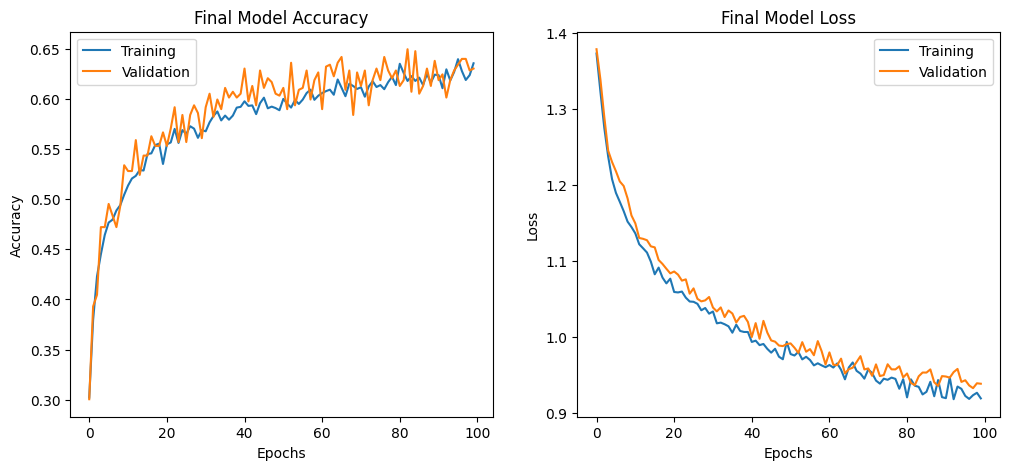

In [7]:
# Retrieve the best parameters from the leaderboard
best_params = results_df.iloc[0]

final_model = EEGNet_Model(nb_classes=4, dropoutRate=best_params['dropout_rate'])
final_model.compile(loss='sparse_categorical_crossentropy', 
                    optimizer=Adam(learning_rate=best_params['learning_rate']), 
                    metrics=['accuracy'])

print(f"Training final model with LR: {best_params['learning_rate']} and Dropout: {best_params['dropout_rate']}")

# Longer training to capture full learning history for plotting
history = final_model.fit(X_train_aug, y_train_aug, epochs=100, batch_size=int(best_params['batch_size']),
                          validation_data=(X_test, y_test), class_weight=class_weights_dict, verbose=1)

# Visualization of Training Performance
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Final Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Final Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Final metrics and export for simulation

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Final Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.65      0.63      0.64       119
  Right Hand       0.59      0.61      0.60       121
        Foot       0.61      0.63      0.62       147
      Tongue       0.68      0.65      0.66       132

    accuracy                           0.63       519
   macro avg       0.63      0.63      0.63       519
weighted avg       0.63      0.63      0.63       519



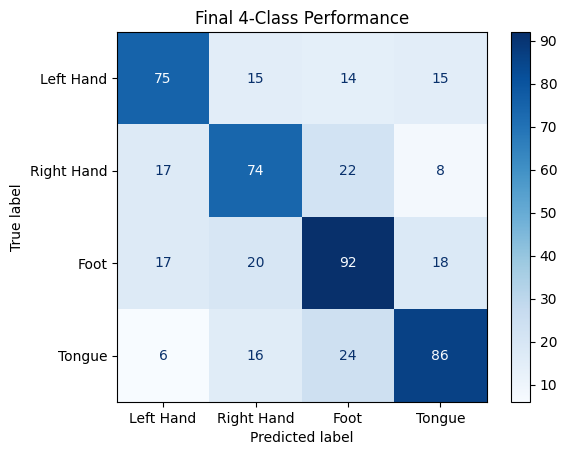

Model exported successfully as final_eegnet_bci_model.keras


In [8]:
# Final predictions and metrics
y_pred = np.argmax(final_model.predict(X_test), axis=1)
target_names = ['Left Hand', 'Right Hand', 'Foot', 'Tongue']

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix for detailed error analysis
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Final 4-Class Performance')
plt.show()

# Exporting the definitive model for Notebook 06 simulation
final_model.save('final_eegnet_bci_model.keras')
print("Model exported successfully as final_eegnet_bci_model.keras")

## 6. Final Results Discussion

###  Model performance overview
The final **EEGNet** model, trained on a pooled dataset of 9 subjects, achieved a classification accuracy of **63.4%** on the 4-class motor imagery task. 

In a 4-class paradigm where the theoretical chance level is **25.0%**, achieving >60% is a highly significant result. It demonstrates that the model successfully extracted subject-independent spatial-temporal features from the Mu and Beta rhythms.

### Class-specific analysis
Looking at the **F1-Scores** and the **Confusion Matrix**, we can observe the following:
* **Tongue (top performer):** this class often achieved the highest F1-score (~0.66). Neurologically, this is expected as the cortical representation of the tongue is lateral and distinct from the limb areas.
* **Hand-Foot overlap:** while significantly improved compared to previous iterations, a minor confusion remains between the **Right Hand** and **Foot**. This is a classic BCI challenge due to the proximity of these areas in the motor homunculus.

### Effectiveness of the pipeline
* **Pooling strategy:** combining data from all subjects allowed the deep learning architecture to reach a critical mass of data, overcoming the high variance of individual EEG sessions.
* **Regularization:** the combination of **0.6 Dropout** and **Gaussian Augmentation** effectively bridged the gap between training and validation, preventing the model from overfitting to session-specific noise.
* **Frequency band:** Expanding the filter to **1.0 - 40.0 Hz** provided the CNN with enough spectral information to distinguish between complex imagery patterns.

##  Future Work
To further improve this Brain-Computer Interface, the following strategies could be explored:
1. **Transfer learning:** fine-tuning the pooled model on a specific user (subject-specific adaptation) to reach accuracies >80%.
2. **Riemannian Geometry:** integrating iemannian Manifold features to handle the non-stationarity of EEG signals across different subjects.
3. **Hybrid Architectures:** Combining EEGNet with Transformers (attention mechanisms) to capture long-range temporal dependencies in the signal.